## 各船の船舶ログから偏流を計算するまでの流れ
1. 複数のログファイルをFileConection.ipynbで１つのファイルにする
1. S1-ShipLogToS1でファイルから必要な情報を抜き出す
1. このファイル(環境省の船舶ログから偏流)で各船の偏流を計算

## import files

In [1]:
%matplotlib inline
import datetime
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from filterpy.gh import GHFilter
from numpy.random import randn
import seaborn as sns
from tqdm import tqdm
import pickle as pkl
import math
import os 
import os.path as osp
import re

import warnings
warnings.simplefilter('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid", palette="muted", color_codes=True)

from utils import *
from kf_params import *

## 関数の定義

In [2]:
def latlon_to_mesh_df(lat, lon, deg_per_mesh=1/36, size=[1050, 1191], latlon_range=[20-1/36, 117-1/36]):
    # lat, lon -> [lon, lat]
    grid0 = ((lon-latlon_range[1]).astype(int)/deg_per_mesh)
    grid1 = ((lat-latlon_range[0]).astype(int)/deg_per_mesh)
    grid0[grid0 < 0] = -1
    grid0[grid0 > size[0]] = -1
    grid1[grid1 < 0] = -1
    grid1[grid1 > size[1]] = -1
    return grid0, grid1

def mean_ground_speed(dt, lat1, lon1, lat2, lon2):
    
    lat1 = dms_to_deg(lat1)
    lon1 = dms_to_deg(lon1)
    
    lat2 = dms_to_deg(lat2)
    lon2 = dms_to_deg(lon2)
    
    dist, deg = dist_deg_latlon(lat1, lon1, lat2, lon2)
    speed = dist/dt
    return ((lat1+lat2)/2, (lon1+lon2)/2), (speed, deg)

def dist_deg_latlon(lat1, lon1, lat2, lon2):
    from geopy.distance import geodesic
    res = geodesic((lat1, lon1), (lat2, lon2))
    
    # 方位角を計算
    lat1_rad = math.radians(lat1)
    lon1_rad = math.radians(lon1)
    lat2_rad = math.radians(lat2)
    lon2_rad = math.radians(lon2)
    delta_lon = lon2_rad - lon1_rad
    y = math.sin(delta_lon) * math.cos(lat2_rad)
    x = math.cos(lat1_rad) * math.sin(lat2_rad) - math.sin(lat1_rad) * math.cos(lat2_rad) * math.cos(delta_lon)
    bearing = math.degrees(math.atan2(y, x))

    # 0から360度の範囲に調整
    bearing = (bearing + 360) % 360
    return res.meters, bearing

def dms_to_deg(x):
    deg = x // 100
    mit = x - deg*100
    #print(x)
    #print(deg)
    #print(mit)
    #print(sec)
    return deg + mit/60

def deg_to_rat(deg):
    #  北基準のdef
    return (-deg+90)*np.pi/180

def remove_outlier(df, key):
    # 下位・上位５％のデータを消す（外れ値対策）
    q1 = df[key].quantile(0.05)
    q2 = df[key].quantile(0.95)
    tf = (df[key]>q1) & (df[key]<q2)
    df2 = df[tf]
    return df2
    
def latlon_knot(lat1, lon1, lat2, lon2):
    distance = haversine_distance(lat1, lon1, lat2, lon2)/60
    knot = (distance/(time_set[i+1]-time_set[i])) * 1.94384
    return knot

In [3]:
path = r"E:\shunsukeE\data\shiplog/"
files = os.listdir(path)
dirs = [f for f in files if os.path.isdir(os.path.join(path, f))]

In [16]:
year = dt_year = 2015
month = dt_month = 9
dt_day = 1
n_day = 1 #nday_month(dt_month)
target_ship = '87東洋'

In [80]:
f_path = r'E:\shunsukeE\data\shiplog\黒潮\2015/黒潮丸FileOut20150904.slog1'
shipLog = pd.read_csv(f_path, encoding="cp932", header=None)
shipLog.columns = ["UTC", "NMEA", "data1", "data2"]

In [81]:
def latlon_to_mesh_df(lat, lon, deg_per_mesh=1/36, size=[1050, 1191], latlon_range=[20-1/36, 117-1/36]):
    # lat, lon -> [lon, lat]
    grid0 = ((lon-latlon_range[1]).astype(int)/deg_per_mesh)
    grid1 = ((lat-latlon_range[0]).astype(int)/deg_per_mesh)
    grid0[grid0 < 0] = -1
    grid0[grid0 > size[0]] = -1
    grid1[grid1 < 0] = -1
    grid1[grid1 > size[1]] = -1
    return grid0, grid1

def mean_ground_speed(dt, lat1, lon1, lat2, lon2):
    
    lat1 = dms_to_deg(lat1)
    lon1 = dms_to_deg(lon1)
    
    lat2 = dms_to_deg(lat2)
    lon2 = dms_to_deg(lon2)
    
    dist, deg = dist_deg_latlon(lat1, lon1, lat2, lon2)
    speed = dist/dt
    return ((lat1+lat2)/2, (lon1+lon2)/2), (speed, deg)

def dist_deg_latlon(lat1, lon1, lat2, lon2):
    from geopy.distance import geodesic
    res = geodesic((lat1, lon1), (lat2, lon2))
    
    # 方位角を計算
    lat1_rad = math.radians(lat1)
    lon1_rad = math.radians(lon1)
    lat2_rad = math.radians(lat2)
    lon2_rad = math.radians(lon2)
    delta_lon = lon2_rad - lon1_rad
    y = math.sin(delta_lon) * math.cos(lat2_rad)
    x = math.cos(lat1_rad) * math.sin(lat2_rad) - math.sin(lat1_rad) * math.cos(lat2_rad) * math.cos(delta_lon)
    bearing = math.degrees(math.atan2(y, x))

    # 0から360度の範囲に調整
    bearing = (bearing + 360) % 360
    return res.meters, bearing

def dms_to_deg(x):
    deg = x // 100
    mit = x - deg*100
    #print(x)
    #print(deg)
    #print(mit)
    #print(sec)
    return deg + mit/60

def deg_to_rat(deg):
    #  北基準のdef
    return (-deg+90)*np.pi/180

def remove_outlier(df, key):
    # 下位・上位５％のデータを消す（外れ値対策）
    q1 = df[key].quantile(0.05)
    q2 = df[key].quantile(0.95)
    tf = (df[key]>q1) & (df[key]<q2)
    df2 = df[tf]
    return df2
    
def latlon_knot(lat1, lon1, lat2, lon2):
    distance = haversine_distance(lat1, lon1, lat2, lon2)/60
    knot = (distance/(time_set[i+1]-time_set[i])) * 1.94384
    return knot

def divide_nmea(log_data):
    # 時間の整理　dtIdx: 0時からの経過時間，dtIdx_Minute:0時0分からの経過分
    time_utc =log_data["UTC"].values
    str_format = '%Y/%m/%d %H:%M:%S'
    epoc_dt = datetime.datetime(dt_year, dt_month, dt_day, 0, 0, 0)
    time_idx = []
    time_idx2 = []
    tf = []
    for t in time_utc:
        idx = datetime.datetime.strptime(t, str_format) 
        idx2 = idx - epoc_dt
        time_idx.append(int(idx2.days*24 + idx2.seconds / (60*60)))
        time_idx2.append(int(idx2.days*24*60 + idx2.seconds / (60)))
    time_idx = np.array(time_idx)
    time_idx2 = np.array(time_idx2)
    log_data["DtIdx"] = time_idx
    log_data["DtIdx_Minute"] = time_idx2

    # NMEAデータの抽出
    # ggaデータの抽出
    gga = log_data[log_data["NMEA"]=="GGA"]
    gga.columns = ['UTC', 'NMEA', 'LatDMS', 'LonDMS', 'DtIdx', 'DtIdx_Minute']
    gga['Lat'] = dms_to_deg(gga['LatDMS'])
    gga['Lon'] = dms_to_deg(gga['LonDMS'])

    # vbwデータの抽出
    vbw = log_data[log_data["NMEA"]=="VBW"]
    vbw.columns = ['UTC', 'NMEA', 'LonWaterSpeed', 'TraWaterSpeed', 'DtIdx', 'DtIdx_Minute']

    
    # hdtデータの抽出
    hdt = log_data[log_data["NMEA"]=="HDT"]
    hdt = hdt.drop('data2', axis=1)
    hdt.columns = ['UTC', 'NMEA', 'HeadDeg', 'DtIdx', 'DtIdx_Minute']

    # vtgデータの抽出    
    vtg = log_data[log_data["NMEA"]=="VTG"]
    vtg.columns = ['UTC', 'NMEA', 'HeadDeg', 'GroundSpeed', 'DtIdx', 'DtIdx_Minute']

    # vtgデータの抽出
    vhw = log_data[log_data["NMEA"]=="VHW"]
    vhw.columns = ['UTC', 'NMEA', 'HeadDeg', 'WaterSpeed', 'DtIdx', 'DtIdx_Minute']
    
    # データ処理
    delete_time_nmri = {}
    stop_knot = 0.5
    
    # vtgデータ処理
    prev_dt = set(vtg['DtIdx_Minute'].values)
    tf = vtg['GroundSpeed']>stop_knot
    vtg = vtg[tf]
    delete_time_nmri['VTG'] = prev_dt - set(vtg['DtIdx_Minute'].values)

    # vbwのデータ処理
    prev_dt = set(vbw['DtIdx_Minute'].values)
    tf = vbw['LonWaterSpeed']!=-999.0
    vbw = vbw[tf] 
    tf = vbw['LonWaterSpeed']>stop_knot
    vbw = vbw[tf] 
    delete_time_nmri['VBW'] = prev_dt - set(vbw['DtIdx_Minute'].values)
    
    # hdtデータ処理
    prev_dt = set(hdt['DtIdx_Minute'].values)
    time_set = sorted(set(hdt["DtIdx_Minute"]))
    delete_range = 10
    thres = (10/180)*np.pi
    for i in range(len(time_set)-1):
            hdt1 = hdt[time_set[i] == hdt["DtIdx_Minute"]]
            hdt2 = hdt[time_set[i+1] == hdt["DtIdx_Minute"]]
            
            hdt1 = remove_outlier(hdt1, 'HeadDeg')
            hdt2 = remove_outlier(hdt2, 'HeadDeg')
            
            headRat1 = deg_to_rat(hdt1['HeadDeg'])
            sin1 = np.mean(np.sin(headRat1))
            cos1 = np.mean(np.cos(headRat1))
            
            headRat2 = deg_to_rat(hdt2['HeadDeg'])
            sin2 = np.mean(np.sin(headRat2))
            cos2 = np.mean(np.cos(headRat2))

            delta_theta = np.arccos(sin1*sin2 + cos1*cos2)
            omega = delta_theta/(time_set[i+1]-time_set[i])
            
            time = time_set[i]
            if np.abs(omega)>thres:
                tf = hdt['DtIdx_Minute']!=time
                hdt = hdt[tf]
                for j in range(1, 10):
                    tf = hdt['DtIdx_Minute']!=time-j
                    hdt = hdt[tf]
                    tf = hdt['DtIdx_Minute']!=time+j
                    hdt = hdt[tf]
    delete_time_nmri['HDT'] = prev_dt - set(hdt['DtIdx_Minute'].values)
    # vhwデータ処理
    prev_dt = set(vhw['DtIdx_Minute'].values)
    tf = vhw['WaterSpeed']!=-999.0
    vhw = vhw[tf]
    tf = vhw['WaterSpeed']>stop_knot
    vhw = vhw[tf]
    delete_time_nmri['VHW'] = prev_dt - set(vhw['DtIdx_Minute'].values)
    
    return gga, vbw, hdt, vtg, vhw, delete_time_nmri

def cur_nmea(gga, vbw, hdt, vtg):
    min_timeHours = np.min(gga["DtIdx"])
    max_timeHours = np.max(gga["DtIdx"])
    num_timeHours = max_timeHours - min_timeHours + 1

    grids0 = []
    grids1 = []
    curN = []
    curE = []
    timeMinutes = []
    timeHours = []
    UTC_time = []
    lats = []
    lons = []
    curN_grid = {}
    curE_grid = {}
    count_grid = {}

    time_set_h = set(gga["DtIdx"])
    for s in time_set_h:
        curN_grid[s] = np.zeros(nan_map.shape)
        curE_grid[s] = np.zeros(nan_map.shape)
        count_grid[s] = np.zeros(nan_map.shape) 

    time_set = set(gga["DtIdx_Minute"])
    for time in time_set:
        print('--------------------')
        gga1 = gga[time == gga["DtIdx_Minute"]]
        vbw1 = vbw[time == vbw["DtIdx_Minute"]]
        hdt1 = hdt[time == hdt["DtIdx_Minute"]]
        vtg1 = vtg[time == vtg["DtIdx_Minute"]]
        if (len(vbw1)==0 or len(gga1)==0 or len(hdt1)==0 or len(vtg1)==0): 
            if len(vbw1)==0:
                print('nodata vbw')
            if len(gga1)==0:
                print('nodata gga') 
            if len(hdt1)==0:
                print('nodata hdt') 
            if len(vtg1)==0:
                print('nodata vtg') 
            continue

        # GGAからLat Lon 取得
        lat1 = np.mean(remove_outlier(gga1, 'Lat')['Lat'])
        lon1 = np.mean(remove_outlier(gga1, 'Lon')['Lon'])
        # データ数が少なすぎると、外れ値消去の際にnanになる，データが少ないときはその時間は計算せずcontinue
        if not lat1==lat1 or not lon1==lon1:
            print('not enought gga data')
            continue

        # HDTから船首方位取得
        headRat = deg_to_rat(hdt1['HeadDeg'])
        sin1 = np.mean(np.sin(headRat))
        cos1 = np.mean(np.cos(headRat))
        

        # VBWから対船水速取得
        water_speed = np.mean(remove_outlier(vbw1, 'LonWaterSpeed')['LonWaterSpeed'])
        if not water_speed==water_speed:
            print('not enought vbw data')
            continue

        # VTGから船首方位・対地船速取得
        g_headRat = deg_to_rat(vtg1['HeadDeg'])
        g_sin1 = np.mean(np.sin(g_headRat))
        g_cos1 = np.mean(np.cos(g_headRat))
        ground_speed = np.mean(remove_outlier(vtg1, 'GroundSpeed')['GroundSpeed'])
        if not ground_speed==ground_speed:
            print('not enought vtg data')
            continue

        # 偏流の計算
        curN.append(ground_speed*g_sin1 - water_speed*sin1)
        curE.append(ground_speed*g_cos1 - water_speed*cos1)
        #curN.append(-water_speed*sin1 + ground_speed*g_sin1)
        #curE.append(-water_speed*cos1 + ground_speed*g_cos1)
        print(f'N {ground_speed*g_sin1 - water_speed*sin1}')
        print(f'E {ground_speed*g_cos1 - water_speed*cos1}')
        
        # Gridの位置計算
        grid0, grid1 = latlon_to_mesh(lat1, lon1)

        grids0.append(grid0)
        grids1.append(grid1)
        lats.append(lat1)
        lons.append(lon1)

        UTC_time.append(gga1['UTC'].values[-1][:-6])
        timeMinutes.append(time)
        timeHours.append(gga1['DtIdx'].values[-1])
        curN_grid[timeHours[-1]][grid0][grid1] += curN[-1]
        curE_grid[timeHours[-1]][grid0][grid1] += curE[-1]
        count_grid[timeHours[-1]][grid0][grid1] += 1
        print('--------------------')

    grid_cur_m = pd.DataFrame([])
    grid_cur_m["DtIdx"] = timeHours
    grid_cur_m["DtIdx_Minute"] = timeMinutes
    grid_cur_m["UTC"] = UTC_time
    grid_cur_m["CurN"] = curN
    grid_cur_m["CurE"] = curE
    grid_cur_m["Grid0"] = grids0
    grid_cur_m["Grid1"] = grids1
    grid_cur_m["Lat"] = lats
    grid_cur_m["Lon"] = lons

    for i in time_set_h:
        count_grid[i][count_grid[i] == 0] += 1
        curN_grid[i] = curN_grid[i]/count_grid[i]
        curE_grid[i] = curE_grid[i]/count_grid[i]
    return grid_cur_m, curN_grid, curE_grid

    for i in time_set_h:
        count_grid[i][count_grid[i] == 0] += 1
        curN_grid[i] = curN_grid[i]/count_grid[i]
        curE_grid[i] = curE_grid[i]/count_grid[i]
    return grid_cur_m, curN_grid, curE_grid

    # vhwデータ処理
    prev_dt = set(vhw['DtIdx_Minute'].values)
    tf = vhw['WaterSpeed']!=-999.0
    vhw = vhw[tf]
    tf = vhw['WaterSpeed']>stop_knot
    vhw = vhw[tf]
    delete_time_nmri['VHW'] = prev_dt - set(vhw['DtIdx_Minute'].values)
    
    return gga, vbw, hdt, vtg, vhw, delete_time_nmri

for target_ship in ["黒潮"]:


    ggas = []
    vbws = []
    hdts = []
    vtgs = []
    vhws = []
    delete_times = []

    log_datas = [shipLog]
    gga, vbw, hdt, vtg, vhw,  delete_time_nmri = divide_nmea(shipLog)
    ggas.append(gga)
    vbws.append(vbw)
    hdts.append(hdt)
    vtgs.append(vtg)
    vhws.append(vhw)
    delete_times.append(delete_time_nmri)
    
    for i in range(len(log_datas)):
        log_data = log_datas[i]
        print(f'--------num data--------')
        print(f'GGA: {len(ggas[i])}')
        print(f'VBW: {len(vbws[i])}')
        print(f'HDT: {len(hdts[i])}')
        print(f'VTG: {len(vtgs[i])}')
        print(f'VHW: {len(vhws[i])}')
        print(f'------------------------\n')

    grid_cur_minute = []
    curN_grid = []
    curE_grid = []
    for i in range(len(ggas)):
        grid_cur, N, E = cur_nmea(ggas[i], vbws[i], hdts[i], vtgs[i])
        grid_cur_minute.append(grid_cur)
        curN_grid.append(N)
        curE_grid.append(E)

    #    print(f'Error {target_ship}')

--------num data--------
GGA: 96314
VBW: 83266
HDT: 83202
VTG: 93308
VHW: 0
------------------------

--------------------
not enought vbw data
--------------------
not enought vbw data
--------------------
N -0.11743703051118715
E 0.21307895080817651
--------------------
--------------------
N -0.13054879170518952
E 0.3529546573147755
--------------------
--------------------
N -0.2109949943615046
E 0.4726070196051264
--------------------
--------------------
not enought vbw data
--------------------
N -0.23753812460911128
E 0.5527104860592011
--------------------
--------------------
not enought vtg data
--------------------
not enought vtg data
--------------------
N -0.3107941021795302
E 0.43027170615354393
--------------------
--------------------
not enought vtg data
--------------------
not enought vbw data
--------------------
not enought vtg data
--------------------
N 0.08627633464709561
E 0.11599860305220311
--------------------
--------------------
not enought vtg data
----

N 0.7844263542754621
E 0.5897460633462028
--------------------
--------------------
N 0.5503793291057832
E 0.644509019956983
--------------------
--------------------
N 0.5911472235079027
E 0.6600462206464428
--------------------
--------------------
N 0.5570861577512041
E 0.6231311842984937
--------------------
--------------------
N 0.8382584071397887
E 0.6492754621321453
--------------------
--------------------
N 0.550263979180031
E 0.6130073549378832
--------------------
--------------------
N 0.5874878682951641
E 0.6617791913743236
--------------------
--------------------
N 0.7053131999678848
E 0.6427142985762728
--------------------
--------------------
N 0.7185530045711501
E 0.708422093773379
--------------------
--------------------
N 0.6081353047904363
E 0.6840308034652338
--------------------
--------------------
not enought vtg data
--------------------
N 0.5231124122457969
E 0.6788910854419736
--------------------
--------------------
N 0.6262384228577202
E 0.591172102220

not enought vtg data
--------------------
N 0.08335436157278586
E 0.07464654308315666
--------------------
--------------------
N 0.10879225743595389
E 0.015165476264888511
--------------------
--------------------
N 0.17546929037241799
E -0.03956227317794614
--------------------
--------------------
N -0.2016323486252647
E -0.1331186399961659
--------------------
--------------------
not enought vtg data
--------------------
not enought vtg data
--------------------
not enought vtg data
--------------------
not enought vtg data
--------------------
not enought vbw data
--------------------
not enought vtg data
--------------------
N -0.0889758658409383
E -0.45786511811277464
--------------------
--------------------
not enought vtg data
--------------------
not enought vtg data
--------------------
not enought vbw data
--------------------
not enought vtg data
--------------------
nodata hdt
--------------------
nodata hdt
--------------------
nodata hdt
--------------------
nodata hd

not enought vtg data
--------------------
not enought vtg data
--------------------
N -0.24230672648118112
E 0.6526851543211709
--------------------
--------------------
N -0.02344540825832908
E 0.4986755806724208
--------------------
--------------------
not enought vtg data
--------------------
N -0.11729521369920892
E 0.3713212264199388
--------------------
--------------------
N -0.022948103193686897
E 0.33581223913620484
--------------------
--------------------
not enought vbw data
--------------------
not enought vtg data
--------------------
N 0.20982417864972458
E 0.319363802760126
--------------------
--------------------
not enought vbw data
--------------------
not enought vtg data
--------------------
not enought vtg data
--------------------
not enought vtg data
--------------------
not enought vtg data
--------------------
not enought vtg data
--------------------
not enought vtg data
--------------------
N 0.2638084560111311
E -0.42321854489785515
--------------------
-

N 1.8055811300914617
E 0.7800191679773416
--------------------
--------------------
N 2.07728989367395
E 0.6192696588288822
--------------------
--------------------
N 1.8961328824096402
E 0.6431596245070033
--------------------
--------------------
N 1.8904135807044433
E 0.6754679193680655
--------------------
--------------------
N 1.8571287509750851
E 0.5572151766878211
--------------------
--------------------
not enought vtg data
--------------------
not enought vtg data
--------------------
N 1.911035681081891
E 0.425106606463304
--------------------
--------------------
N 1.8534293702571576
E 0.4476273379332927
--------------------
--------------------
not enought vtg data
--------------------
not enought vbw data
--------------------
not enought vtg data
--------------------
N 1.677664132176198
E 0.4081003442802764
--------------------
--------------------
N 1.5463747311831666
E 0.5092801106943874
--------------------
--------------------
N 1.4886345647546517
E 0.54523696154517

not enought vtg data
--------------------
not enought vtg data
--------------------
not enought vtg data
--------------------
not enought vbw data
--------------------
not enought vtg data
--------------------
not enought vtg data
--------------------
not enought vtg data
--------------------
not enought vbw data
--------------------
not enought vtg data
--------------------
not enought vtg data
--------------------
not enought vtg data
--------------------
N -0.007428294293289284
E 0.30498693388089215
--------------------
--------------------
not enought vtg data
--------------------
N -0.054356684738683825
E 0.5675548277549982
--------------------
--------------------
not enought vtg data
--------------------
not enought vtg data
--------------------
not enought vbw data
--------------------
not enought vtg data
--------------------
not enought vbw data
--------------------
not enought vtg data
--------------------
not enought vtg data
--------------------
not enought vbw data
------

not enought vtg data
--------------------
not enought vtg data
--------------------
not enought vtg data
--------------------
N -0.5395024339055174
E -0.28326306373228327
--------------------
--------------------
not enought vtg data
--------------------
not enought vbw data
--------------------
nodata hdt
--------------------
nodata hdt
--------------------
nodata hdt
--------------------
nodata hdt
--------------------
nodata hdt
--------------------
nodata hdt
--------------------
nodata hdt
--------------------
nodata hdt
--------------------
nodata hdt
--------------------
nodata hdt
--------------------
nodata hdt
--------------------
nodata hdt
--------------------
nodata hdt
--------------------
nodata hdt
--------------------
nodata hdt
--------------------
nodata hdt
--------------------
nodata hdt
--------------------
nodata hdt
--------------------
nodata hdt
--------------------
nodata hdt
--------------------
nodata hdt
--------------------
nodata hdt
--------------------

not enought vtg data
--------------------
not enought vtg data
--------------------
not enought vtg data
--------------------
not enought vtg data
--------------------
not enought vtg data
--------------------
not enought vtg data
--------------------
not enought vtg data
--------------------
N -1.1385305706793307
E 1.3336811739665038
--------------------
--------------------
not enought vtg data
--------------------
not enought vtg data
--------------------
not enought vtg data
--------------------
not enought vtg data
--------------------
not enought vtg data
--------------------
not enought vtg data
--------------------
not enought vtg data
--------------------
N -0.9138860297090776
E 0.20127550255325488
--------------------
--------------------
not enought vtg data
--------------------
not enought vtg data
--------------------
N -0.4477696355633256
E 0.12393854353380362
--------------------
--------------------
N -0.25211799821071423
E -0.01640525055135278
--------------------
----

not enought vbw data
--------------------
not enought vbw data
--------------------
not enought vbw data
--------------------
not enought vtg data
--------------------
not enought vtg data
--------------------
not enought vbw data
--------------------
not enought vbw data
--------------------
not enought vbw data
--------------------
not enought vbw data
--------------------
not enought vbw data
--------------------
not enought vtg data
--------------------
not enought vbw data
--------------------
not enought vbw data
--------------------
not enought vbw data
--------------------
not enought vbw data
--------------------
not enought vbw data
--------------------
not enought vbw data
--------------------
not enought vtg data
--------------------
not enought vbw data
--------------------
not enought vbw data
--------------------
not enought vbw data
--------------------
not enought vbw data
--------------------
not enought vbw data
--------------------
not enought vbw data
-------------

In [82]:
len(shipLog[shipLog["NMEA"]=="HDT"])

96314

In [83]:
len(hdt)

83202

In [84]:
shipLog

,UTC,NMEA,data1,data2,DtIdx,DtIdx_Minute
0,2015/09/04 14:50:00,GGA,3350.055,13104.186,86,5210
1,2015/09/04 14:50:00,VTG,290.200,0.000,86,5210
2,2015/09/04 14:50:00,HDT,42.000,NaN,86,5210
3,2015/09/04 14:50:00,VBW,0.300,-999.000,86,5210
4,2015/09/04 14:50:01,GGA,3350.055,13104.186,86,5210
...,...,...,...,...,...,...
375081,2015/09/03 21:49:58,VBW,13.500,-999.000,69,4189
375082,2015/09/03 21:49:58,GGA,3319.550,13429.089,69,4189
375083,2015/09/03 21:49:58,VTG,246.400,13.100,69,4189
375084,2015/09/03 21:49:58,HDT,248.000,NaN,69,4189


<Axes: xlabel='DtIdx_Minute', ylabel='data1'>

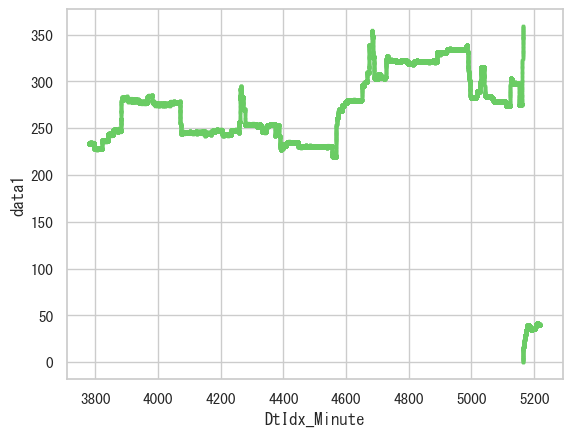

In [85]:
raw_hdt = log_data[shipLog["NMEA"]=="HDT"]
raw_hdt.plot.scatter(x='DtIdx_Minute', y='data1',
                marker='s', c='g', s=1, alpha=0.5)  

<Axes: xlabel='DtIdx_Minute', ylabel='HeadDeg'>

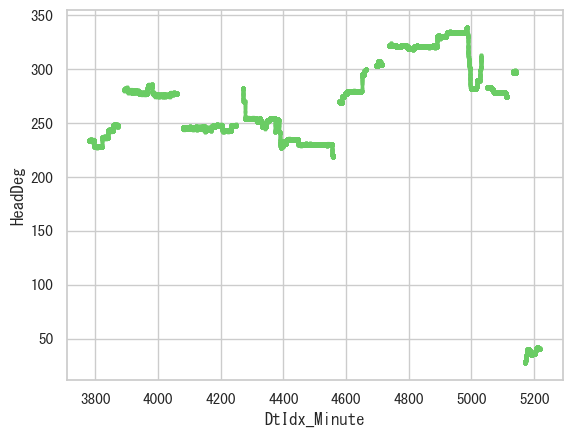

In [86]:
hdt.plot.scatter(x='DtIdx_Minute', y='HeadDeg',
                marker='s', c='g', s=1, alpha=0.5)  

In [90]:
over = grid_cur[grid_cur['CurN']>1.0]
over

,DtIdx,DtIdx_Minute,UTC,CurN,CurE,Grid0,Grid1,Lat,Lon
281,71,4276,2015/09/03 23,1.401019,1.220701,606,617,33.221753,134.118003
308,71,4311,2015/09/03 23,1.000884,0.698972,607,612,33.190739,133.975401
310,71,4313,2015/09/03 23,1.138174,0.630277,607,611,33.189243,133.966949
311,71,4314,2015/09/03 23,1.126508,0.658385,607,611,33.188515,133.962716
312,71,4315,2015/09/03 23,1.213200,0.446761,607,611,33.187830,133.958426
313,72,4325,2015/09/04 0,1.611432,0.697054,607,609,33.179534,133.916089
314,72,4326,2015/09/04 0,1.514223,0.703829,607,609,33.178817,133.911811
315,72,4327,2015/09/04 0,1.536855,0.693264,607,609,33.178127,133.907529
316,72,4328,2015/09/04 0,1.732115,0.770187,607,609,33.177293,133.903162
317,72,4329,2015/09/04 0,1.805581,0.780019,607,609,33.176558,133.898883


In [98]:
target = log_data[log_data['DtIdx_Minute']==4344]
gga, vbw, hdt, vtg, vhw,  delete_time_nmri = divide_nmea(target)

In [127]:
vtg.describe()

,HeadDeg,GroundSpeed,DtIdx,DtIdx_Minute
count,66.000000,66.000000,66.0,66.0
mean,251.390909,12.918182,72.0,4344.0
std,1.908904,0.110814,0.0,0.0
min,247.500000,12.700000,72.0,4344.0
25%,250.325000,12.800000,72.0,4344.0
50%,251.350000,12.900000,72.0,4344.0
75%,252.800000,13.000000,72.0,4344.0
max,254.500000,13.200000,72.0,4344.0


In [128]:
vbw.describe()

,LonWaterSpeed,TraWaterSpeed,DtIdx,DtIdx_Minute
count,60.00000,60.0,60.0,60.0
mean,14.11000,-999.0,72.0,4344.0
std,0.07524,0.0,0.0,0.0
min,14.00000,-999.0,72.0,4344.0
25%,14.10000,-999.0,72.0,4344.0
50%,14.10000,-999.0,72.0,4344.0
75%,14.20000,-999.0,72.0,4344.0
max,14.20000,-999.0,72.0,4344.0


In [131]:
hdt.describe()

,HeadDeg,DtIdx,DtIdx_Minute
count,66.000000,66.0,66.0
mean,246.378788,72.0,4344.0
std,0.575531,0.0,0.0
min,246.000000,72.0,4344.0
25%,246.000000,72.0,4344.0
50%,246.000000,72.0,4344.0
75%,247.000000,72.0,4344.0
max,248.000000,72.0,4344.0


In [105]:
def cur_nmea(gga, vbw, hdt, vtg):
    min_timeHours = np.min(gga["DtIdx"])
    max_timeHours = np.max(gga["DtIdx"])
    num_timeHours = max_timeHours - min_timeHours + 1

    grids0 = []
    grids1 = []
    curN = []
    curE = []
    timeMinutes = []
    timeHours = []
    UTC_time = []
    lats = []
    lons = []
    curN_grid = {}
    curE_grid = {}
    count_grid = {}

    time_set_h = set(gga["DtIdx"])
    for s in time_set_h:
        curN_grid[s] = np.zeros(nan_map.shape)
        curE_grid[s] = np.zeros(nan_map.shape)
        count_grid[s] = np.zeros(nan_map.shape) 

    time_set = set(gga["DtIdx_Minute"])
    for time in time_set:
        print('--------------------')
        gga1 = gga[time == gga["DtIdx_Minute"]]
        vbw1 = vbw[time == vbw["DtIdx_Minute"]]
        hdt1 = hdt[time == hdt["DtIdx_Minute"]]
        vtg1 = vtg[time == vtg["DtIdx_Minute"]]
        if (len(vbw1)==0 or len(gga1)==0 or len(hdt1)==0 or len(vtg1)==0): 
            if len(vbw1)==0:
                print('nodata vbw')
            if len(gga1)==0:
                print('nodata gga') 
            if len(hdt1)==0:
                print('nodata hdt') 
            if len(vtg1)==0:
                print('nodata vtg') 
            continue

        # GGAからLat Lon 取得
        lat1 = np.mean(remove_outlier(gga1, 'Lat')['Lat'])
        lon1 = np.mean(remove_outlier(gga1, 'Lon')['Lon'])
        # データ数が少なすぎると、外れ値消去の際にnanになる，データが少ないときはその時間は計算せずcontinue
        if not lat1==lat1 or not lon1==lon1:
            print('not enought gga data')
            continue

        # HDTから船首方位取得
        headRat = deg_to_rat(hdt1['HeadDeg'])
        sin1 = np.mean(np.sin(headRat))
        cos1 = np.mean(np.cos(headRat))
        

        # VBWから対船水速取得
        water_speed = np.mean(remove_outlier(vbw1, 'LonWaterSpeed')['LonWaterSpeed'])
        if not water_speed==water_speed:
            print('not enought vbw data')
            continue

        # VTGから船首方位・対地船速取得
        g_headRat = deg_to_rat(vtg1['HeadDeg'])
        g_sin1 = np.mean(np.sin(g_headRat))
        g_cos1 = np.mean(np.cos(g_headRat))
        ground_speed = np.mean(remove_outlier(vtg1, 'GroundSpeed')['GroundSpeed'])
        if not ground_speed==ground_speed:
            print('not enought vtg data')
            continue

        # 偏流の計算
        print(f'--ground speed sin cos--')
        print(ground_speed)
        print(g_sin1)
        print(g_cos1)
        print(f'--water speed sin cos--')
        
        print(water_speed)
        print(sin1)
        print(cos1)
        print(f'----')
        curN.append(ground_speed*g_sin1 - water_speed*sin1)
        curE.append(ground_speed*g_cos1 - water_speed*cos1)
        #curN.append(-water_speed*sin1 + ground_speed*g_sin1)
        #curE.append(-water_speed*cos1 + ground_speed*g_cos1)
        print(f'N {ground_speed*g_sin1 - water_speed*sin1}')
        print(f'E {ground_speed*g_cos1 - water_speed*cos1}')
        
        # Gridの位置計算
        grid0, grid1 = latlon_to_mesh(lat1, lon1)

        grids0.append(grid0)
        grids1.append(grid1)
        lats.append(lat1)
        lons.append(lon1)

        UTC_time.append(gga1['UTC'].values[-1][:-6])
        timeMinutes.append(time)
        timeHours.append(gga1['DtIdx'].values[-1])
        curN_grid[timeHours[-1]][grid0][grid1] += curN[-1]
        curE_grid[timeHours[-1]][grid0][grid1] += curE[-1]
        count_grid[timeHours[-1]][grid0][grid1] += 1
        print('--------------------')

    grid_cur_m = pd.DataFrame([])
    grid_cur_m["DtIdx"] = timeHours
    grid_cur_m["DtIdx_Minute"] = timeMinutes
    grid_cur_m["UTC"] = UTC_time
    grid_cur_m["CurN"] = curN
    grid_cur_m["CurE"] = curE
    grid_cur_m["Grid0"] = grids0
    grid_cur_m["Grid1"] = grids1
    grid_cur_m["Lat"] = lats
    grid_cur_m["Lon"] = lons

    for i in time_set_h:
        count_grid[i][count_grid[i] == 0] += 1
        curN_grid[i] = curN_grid[i]/count_grid[i]
        curE_grid[i] = curE_grid[i]/count_grid[i]
    return grid_cur_m, curN_grid, curE_grid

    for i in time_set_h:
        count_grid[i][count_grid[i] == 0] += 1
        curN_grid[i] = curN_grid[i]/count_grid[i]
        curE_grid[i] = curE_grid[i]/count_grid[i]
    return grid_cur_m, curN_grid, curE_grid
grid_cur, N, E = cur_nmea(gga, vbw, hdt, vtg)

--------------------
--ground speed sin cos--
12.941463414634146
-0.3189340450503811
-0.9472003038606978
--water speed sin cos--
14.100000000000001
-0.40066853813453285
-0.9161688472056236
----
N 1.5219531119961287
E 0.6598226668557281
--------------------


In [121]:
def deg_to_rat(deg):
    #  北基準のdef
    return (-deg+90)*np.pi/180
np.sin(deg_to_rat(251.39))

-0.31912472123221297

In [130]:
12.94 * (-0.3189)  - 14.10 * (-0.4006)

1.5218939999999996

In [126]:
12.94 * (-0.9472)  - 14.10 * (-0.9162)

0.6616520000000001

In [57]:
def divide_nmea(log_data):
    # 時間の整理　dtIdx: 0時からの経過時間，dtIdx_Minute:0時0分からの経過分
    time_utc =log_data["UTC"].values
    str_format = '%Y/%m/%d %H:%M:%S'
    epoc_dt = datetime.datetime(dt_year, dt_month, dt_day, 0, 0, 0)
    time_idx = []
    time_idx2 = []
    tf = []
    for t in time_utc:
        idx = datetime.datetime.strptime(t, str_format) 
        idx2 = idx - epoc_dt
        time_idx.append(int(idx2.days*24 + idx2.seconds / (60*60)))
        time_idx2.append(int(idx2.days*24*60 + idx2.seconds / (60)))
    time_idx = np.array(time_idx)
    time_idx2 = np.array(time_idx2)
    log_data["DtIdx"] = time_idx
    log_data["DtIdx_Minute"] = time_idx2

    # NMEAデータの抽出
    # ggaデータの抽出
    gga = log_data[log_data["NMEA"]=="GGA"]
    gga.columns = ['UTC', 'NMEA', 'LatDMS', 'LonDMS', 'DtIdx', 'DtIdx_Minute']
    gga['Lat'] = dms_to_deg(gga['LatDMS'])
    gga['Lon'] = dms_to_deg(gga['LonDMS'])

    # vbwデータの抽出
    vbw = log_data[log_data["NMEA"]=="VBW"]
    vbw.columns = ['UTC', 'NMEA', 'LonWaterSpeed', 'TraWaterSpeed', 'DtIdx', 'DtIdx_Minute']

    
    # hdtデータの抽出
    hdt = log_data[log_data["NMEA"]=="HDT"]
    hdt = hdt.drop('data2', axis=1)
    hdt.columns = ['UTC', 'NMEA', 'HeadDeg', 'DtIdx', 'DtIdx_Minute']

    # vtgデータの抽出    
    vtg = log_data[log_data["NMEA"]=="VTG"]
    vtg.columns = ['UTC', 'NMEA', 'HeadDeg', 'GroundSpeed', 'DtIdx', 'DtIdx_Minute']

    # vtgデータの抽出
    vhw = log_data[log_data["NMEA"]=="VHW"]
    vhw.columns = ['UTC', 'NMEA', 'HeadDeg', 'WaterSpeed', 'DtIdx', 'DtIdx_Minute']
    
    
    return gga, vbw, hdt, vtg, vhw


In [58]:
gga, vbw, hdt, vtg, vhw = divide_nmea(shipLog)

In [22]:
vtg

,UTC,NMEA,HeadDeg,GroundSpeed,DtIdx,DtIdx_Minute
1,2015/09/30 14:30:00,VTG,31.0,0.5,710,42630
4,2015/09/30 14:30:01,VTG,32.0,0.5,710,42630
7,2015/09/30 14:30:02,VTG,32.0,0.5,710,42630
10,2015/09/30 14:30:03,VTG,31.0,0.5,710,42630
13,2015/09/30 14:30:04,VTG,31.0,0.5,710,42630
...,...,...,...,...,...,...
179545,2015/09/30 1:39:54,VTG,254.0,0.0,697,41859
179548,2015/09/30 1:39:55,VTG,254.0,0.0,697,41859
179551,2015/09/30 1:39:56,VTG,254.0,0.0,697,41859
179554,2015/09/30 1:39:57,VTG,254.0,0.0,697,41859


In [25]:
len(vtg)

59853

In [24]:
np.sum(vtg['GroundSpeed']>0.5)

20386

In [28]:
tf = vtg['GroundSpeed']>0.5
vtg2 = vtg[tf]
set(vtg2['DtIdx'].values)

{687, 688, 689, 690, 691, 692, 693, 697, 698, 702, 710}

In [30]:
sorted(set(vtg['DtIdx'].values))

[687,
 688,
 689,
 690,
 691,
 692,
 693,
 694,
 695,
 696,
 697,
 698,
 699,
 700,
 701,
 702,
 703,
 704,
 705,
 706,
 707,
 708,
 709,
 710]

In [39]:
tf = vtg['GroundSpeed']>0.5
vtg2 = vtg[tf]
time = sorted(set(vtg2['DtIdx'].values))
def split_into_ranges(lst):
    ranges = []
    current_range = [lst[0]]

    for i in range(1, len(lst)):
        if lst[i] - lst[i-1] == 1:
            current_range.append(lst[i])
        else:
            ranges.append(current_range)
            current_range = [lst[i]]

    ranges.append(current_range)
    return ranges
splited = split_into_ranges(time)
vtg2 = vtg[vtg['DtIdx'].isin(splited[0])]
time = sorted(set(vtg2['DtIdx'].values))
time

[687, 688, 689, 690, 691, 692, 693]

In [40]:
pd.concat([vtg, vtg2])

,UTC,NMEA,HeadDeg,GroundSpeed,DtIdx,DtIdx_Minute
1,2015/09/30 14:30:00,VTG,31.0,0.5,710,42630
4,2015/09/30 14:30:01,VTG,32.0,0.5,710,42630
7,2015/09/30 14:30:02,VTG,32.0,0.5,710,42630
10,2015/09/30 14:30:03,VTG,31.0,0.5,710,42630
13,2015/09/30 14:30:04,VTG,31.0,0.5,710,42630
...,...,...,...,...,...,...
177925,2015/09/29 18:49:55,VTG,52.0,11.8,690,41449
177928,2015/09/29 18:49:56,VTG,52.0,11.8,690,41449
177931,2015/09/29 18:49:57,VTG,52.0,11.8,690,41449
177934,2015/09/29 18:49:58,VTG,52.0,11.8,690,41449


In [43]:
vtg2 = vtg[vtg['DtIdx'].isin(splited[0])]
fname = f'test.png'
plt.figure()
plt.title('GroundSpeed raw')
vtg2.plot.scatter(x='DtIdx_Minute', y='GroundSpeed')
plt.savefig(fname)
plt.close('all')

In [54]:
i=0
count = 0
splited_time = splited
max_voyage_num = 2

sns.set(style="whitegrid", palette="muted", color_codes=True)
plt.rcParams['font.family'] = 'MS Gothic' 
fig, axes = plt.subplots(nrows=max_voyage_num, ncols=5, figsize=(4*5, 4*max_voyage_num))
ax = axes[count, 0]
ax.set_title(f'GGA voyage-{i}')
gga1 = gga[gga['DtIdx'].isin(splited_time[i])]
gga1.plot.scatter(x='Lon', y='Lat',
    marker='s', c='b', s=50, alpha=0.5, ax=ax)

ax = axes[count, 1]
ax.set_title(f'VTG (COG) voyage-{i}')
vtg1 = vtg[vtg['DtIdx'].isin(splited_time[i])]
vtg1.plot.scatter(x='DtIdx', y='HeadDeg',
    marker='s', c='b', s=50, alpha=0.5, ax=ax)          

ax = axes[count, 2]
ax.set_title(f'VTG (SOG) voyage-{i}')
vtg1.plot.scatter(x='DtIdx', y='GroundSpeed',
    marker='s', c='b', s=50, alpha=0.5, ax=ax) 

ax = axes[count, 3]
ax.set_title(f'HDT (HDT) voyage-{i}')
hdt1 = hdt[hdt['DtIdx'].isin(splited_time[i])]
hdt1.plot.scatter(x='DtIdx', y='HeadDeg',
    marker='s', c='b', s=50, alpha=0.5, ax=ax)  

ax = axes[count, 4]
ax.set_title(f'VBW, VHW (STW) voyage-{i}')
vbw1 = vbw[vbw['DtIdx'].isin(splited_time[i])]
if len(vbw1)>0:
    vbw1.plot.scatter(x='DtIdx', y='WaterSpeed',
        marker='s', c='b', s=50, alpha=0.5, ax=ax, label='VBW')
vhw1 = vhw[vhw['DtIdx'].isin(splited_time[i])]
if len(vhw1)>0:
    vhw1.plot.scatter(x='DtIdx', y='WaterSpeed',
    marker='s', c='b', s=50, alpha=0.5, ax=ax, label='VHW') 

plt.title(f'voyage-{target_ship}')
fname = f'voyage-{i}.png'
plt.savefig(fname)
plt.close('all')